# Burgers Orientation Relationship: Composite TEM Diffraction for $[110]_\beta$

This notebook demonstrates how to generate a composite selected-area electron diffraction (SAED) pattern
for the body-centred cubic (bcc) $\beta$ phase observed along the $[110]_\beta$ zone axis together with all
Burgers orientation relationship (OR) variants of the hexagonal close-packed (hcp) $\alpha$ phase.

The Burgers OR is defined by the parallelism conditions

\begin{aligned}
(110)_\beta &\parallel (0001)_\alpha, \\ 
[1\bar{1}1]_\beta &\parallel [11\bar{2}0]_\alpha.
\end{aligned}

These relations minimise the shear and dilatational components of the martensitic transformation from bcc to hcp
and lead to 12 crystallographically equivalent variants. We use **orix** to handle the symmetry-aware orientation
operations and **pymatgen** to generate deterministic electron diffraction patterns.

## Orientation relationship background

For a Burgers transformation, the crystallographic correspondence between the parent ($\beta$) and product ($\alpha$) phases can be
expressed with a transformation matrix $\mathbf{R}_{\alpha \to \beta}$ that rotates the $\alpha$ lattice vectors into the $\beta$ frame. If
$\mathbf{B}_\beta=[\hat{\mathbf{d}}_\beta, \hat{\mathbf{t}}_\beta, \hat{\mathbf{n}}_\beta]$ collects an orthonormal basis constructed from
$[1\bar{1}1]_\beta$, $[\bar{1}\bar{1}2]_\beta$, and $(110)_\beta$, and $\mathbf{B}_\alpha=[\hat{\mathbf{d}}_\alpha, \hat{\mathbf{t}}_\alpha, \hat{\mathbf{n}}_\alpha]$
contains the corresponding $[11\bar{2}0]_\alpha$, $[10\bar{1}0]_\alpha$, and $(0001)_\alpha$ directions, then

\[
\mathbf{R}_{\alpha \to \beta} = \mathbf{B}_\beta \mathbf{B}_\alpha^{-1}.
\]

Applying all proper symmetry operators $\{g_i\}$ of the $\beta$ phase and accounting for the child symmetry $\{h_j\}$ generates the 12 Burgers variants as cosets
$\mathbf{R}_i = g_i \mathbf{R}_{\alpha \to \beta} h_j$ that are distinct modulo $\alpha$-symmetry.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymatgen.core import Lattice, Structure
from pymatgen.core.operations import SymmOp
from pymatgen.analysis.diffraction.tem import TEMCalculator
from orix.quaternion import Orientation
from orix.crystal_map import Phase

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)

### Helper functions
We define utilities to convert Miller-Bravais indices to three-index directions, normalise vectors, and enumerate Burgers variants using **orix** symmetry handling.

In [2]:
def normalize(vector: np.ndarray) -> np.ndarray:
    """Return the unit vector."""
    v = np.asarray(vector, dtype=float)
    return v / np.linalg.norm(v)

def uvw_from_uVTW(U: int, V: int, T: int, W: int) -> np.ndarray:
    """Convert hexagonal four-index direction [UVTW] to the three-index [uvw] form."""
    u = (2 * U + V) / 3
    v = (2 * V + U) / 3
    w = W
    return np.array([u, v, w], dtype=float)

def burgers_orientation(a_beta: float, a_alpha: float, c_alpha: float) -> Orientation:
    """Construct the Burgers OR orientation mapping the alpha lattice into the beta frame."""
    lattice_beta = Lattice.cubic(a_beta)
    lattice_alpha = Lattice.hexagonal(a_alpha, c_alpha)

    n_beta = lattice_beta.reciprocal_lattice_crystallographic.matrix.dot([1, 1, 0])
    d_beta = lattice_beta.matrix.dot([1, -1, 1])
    t_beta = np.cross(n_beta, d_beta)

    d_alpha = lattice_alpha.matrix.dot(uvw_from_uVTW(1, 1, -2, 0))
    n_alpha = lattice_alpha.reciprocal_lattice_crystallographic.matrix.dot([0, 0, 1])
    t_alpha = np.cross(n_alpha, d_alpha)

    basis_beta = np.column_stack([normalize(d_beta), normalize(t_beta), normalize(n_beta)])
    basis_alpha = np.column_stack([normalize(d_alpha), normalize(t_alpha), normalize(n_alpha)])

    rotation = basis_beta @ np.linalg.inv(basis_alpha)
    return Orientation.from_matrix(rotation)

def enumerate_burgers_variants(base: Orientation, parent_pg: str = 'm-3m', child_pg: str = '6/mmm') -> list:
    """Enumerate Burgers variants by applying parent symmetry and removing child-equivalent duplicates."""
    parent_sym = Phase(point_group=parent_pg).point_group
    child_sym = Phase(point_group=child_pg).point_group

    variants: list[Orientation] = []
    for g in parent_sym:
        candidate = g * base
        candidate_matrix = candidate.to_matrix()[0]
        is_new = True
        for existing in variants:
            if np.allclose(candidate_matrix, existing.to_matrix()[0], atol=1e-6):
                is_new = False
                break
            for h in child_sym:
                combo = (existing * h).to_matrix()[0]
                if np.allclose(candidate_matrix, combo, atol=1e-6):
                    is_new = False
                    break
            if not is_new:
                break
        if is_new:
            variants.append(candidate)
    return variants

### Lattice definitions and Burgers variants
We choose representative lattice parameters for metastable $\beta$-Ti (bcc, $a_\beta = 3.23\,\text{Å}$) and equilibrium $\alpha$-Ti (hcp, $a_\alpha = 2.95\,\text{Å}$, $c_\alpha = 4.68\,\text{Å}$).
The resulting Burgers OR matrix is shown together with the count of unique variants.

In [3]:
a_beta = 3.23  # Angstrom
alpha_params = dict(a=2.95, c=4.68)

beta_structure = Structure(Lattice.cubic(a_beta), ['Ti'], [[0, 0, 0]])
alpha_structure = Structure(Lattice.hexagonal(**alpha_params), ['Ti', 'Ti'], [[0, 0, 0], [2/3, 1/3, 1/2]])

base_orientation = burgers_orientation(a_beta=a_beta, a_alpha=alpha_params['a'], c_alpha=alpha_params['c'])
variants = enumerate_burgers_variants(base_orientation)

rotation_matrix = base_orientation.to_matrix()[0]
print('Burgers OR rotation matrix (alpha -> beta):')
print(rotation_matrix)
print(f'Number of Burgers variants: {len(variants)}')

Burgers OR rotation matrix (alpha -> beta):
[[ 0.4018  0.5818  0.7071]
 [-0.4018 -0.5818  0.7071]
 [ 0.8228 -0.5683 -0.    ]]
Number of Burgers variants: 12


### TEM diffraction pattern calculation
We use `TEMCalculator` from **pymatgen** to compute SAED patterns for the $[110]_\beta$ zone axis. The parent pattern is generated directly from the bcc lattice, while each $\alpha$ variant is rotated into the $\beta$ frame before computing its contribution.

In [4]:
calc = TEMCalculator(beam_direction=(1, 1, 0), voltage=200, camera_length=160)
parent_pattern = calc.get_pattern(beta_structure).assign(phase='beta', variant='parent')

variant_patterns = []
for idx, variant in enumerate(variants, start=1):
    rotated = alpha_structure.copy()
    symmop = SymmOp.from_rotation_and_translation(variant.to_matrix()[0], [0, 0, 0])
    rotated.apply_operation(symmop)
    df = calc.get_pattern(rotated)
    df = df.assign(phase='alpha', variant=f'variant_{idx:02d}')
    variant_patterns.append(df)

composite_pattern = pd.concat([parent_pattern, *variant_patterns], ignore_index=True)
print(composite_pattern.head())
print(composite_pattern['variant'].unique())

                                  Position           (hkl)  Intensity (norm)  \
0  [12.423202692890285, -17.5690617363954]  (10, -10, -10)          0.000045   
1  [11.180882423601258, -17.5690617363954]   (10, -10, -9)          0.000064   
2   [9.938562154312226, -17.5690617363954]   (10, -10, -8)          0.000087   
3   [8.696241885023198, -17.5690617363954]   (10, -10, -7)          0.000115   
4   [7.453921615734171, -17.5690617363954]   (10, -10, -6)          0.000146   

   Film radius  Interplanar Spacing phase variant  
0     0.010198             0.186484  beta  parent  
1     0.010198             0.192686  beta  parent  
2     0.010198             0.198793  beta  parent  
3     0.010198             0.204693  beta  parent  
4     0.010198             0.210255  beta  parent  
['parent' 'variant_01' 'variant_02' 'variant_03' 'variant_04' 'variant_05'
 'variant_06' 'variant_07' 'variant_08' 'variant_09' 'variant_10'
 'variant_11' 'variant_12']


The composite table can be inspected quantitatively. Below we aggregate the total normalised intensity contributed by each phase and list the strongest reflections for the first three $\alpha$ variants.

In [5]:
intensity_by_phase = composite_pattern.groupby('phase')['Intensity (norm)'].sum()
variant_preview = (
    composite_pattern[composite_pattern['phase'] == 'alpha']
    .sort_values('Intensity (norm)', ascending=False)
    .groupby('variant')
    .head(3)
)

print('Total normalised intensity by phase:')
print(intensity_by_phase)
variant_preview.head(9)

Total normalised intensity by phase:
phase
alpha    137.949669
beta       8.622543
Name: Intensity (norm), dtype: float64


,Position,(hkl),Intensity (norm),Film radius,Interplanar Spacing,phase,variant
2536,"[-1.7148266964972492, 1.0579456790960332e-16]","(0, 0, 2)",1.0,0.010198,2.34,alpha,variant_05
2533,"[1.7148266964972492, -1.0579456790960332e-16]","(0, 0, -2)",1.0,0.010198,2.34,alpha,variant_05
4377,"[1.7148266964972492, -1.0579456790960332e-16]","(0, 0, -2)",1.0,0.010198,2.34,alpha,variant_09
5763,"[-1.7148266964972492, 1.0579456790960332e-16]","(0, 0, 2)",1.0,0.010198,2.34,alpha,variant_12
5760,"[1.7148266964972492, -1.0579456790960332e-16]","(0, 0, -2)",1.0,0.010198,2.34,alpha,variant_12
2997,"[-1.7148266964972492, 1.057945679096033e-16]","(0, 0, 2)",1.0,0.010198,2.34,alpha,variant_06
2994,"[1.7148266964972492, -1.057945679096033e-16]","(0, 0, -2)",1.0,0.010198,2.34,alpha,variant_06
1153,"[-1.7148266964972496, 1.0579456790960337e-16]","(0, 0, 2)",1.0,0.010198,2.34,alpha,variant_02
1150,"[1.7148266964972496, -1.0579456790960337e-16]","(0, 0, -2)",1.0,0.010198,2.34,alpha,variant_02


### Composite diffraction plot
The scatter plot overlays the parent $\beta$ reflections and all $\alpha$ variants. Marker size scales with the normalised intensity to emphasise dominant reflections.

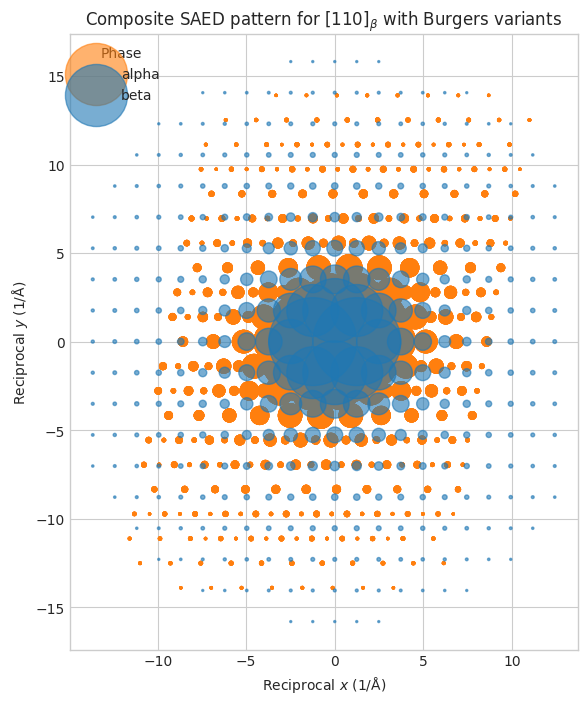

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
phase_colors = {'beta': 'tab:blue', 'alpha': 'tab:orange'}
plot_data = composite_pattern[composite_pattern['Intensity (norm)'] > 5e-4]

for phase, subset in plot_data.groupby('phase'):
    sizes = 4000 * subset['Intensity (norm)']
    positions = np.stack(subset['Position'].to_numpy())
    ax.scatter(positions[:, 0], positions[:, 1], s=sizes, alpha=0.6, label=phase, c=phase_colors[phase])

ax.set_xlabel('Reciprocal $x$ (1/\u212b)')
ax.set_ylabel('Reciprocal $y$ (1/\u212b)')
ax.set_title('Composite SAED pattern for $[110]_{\\beta}$ with Burgers variants')
ax.set_aspect('equal')
ax.legend(title='Phase')
ax.grid(True)
plt.show()

## Discussion
The Burgers OR produces 12 $\alpha$ variants that populate characteristic $\{10\bar{1}0\}_\alpha$ reflections around the parent $\{110\}_\beta$ positions.
The composite pattern highlights how variant superposition explains experimentally observed streaking and spot splitting in $[110]_\beta$ SAED patterns.
Parameters such as accelerating voltage, camera length, and intensity thresholding can be adjusted to match specific experimental setups.